Ethan Ho
017157582
CMPE 188

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import set_option
from sklearn.preprocessing import StandardScaler, Normalizer, LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import RFE
from numpy import set_printoptions
import seaborn as sns
from pandas.plotting import scatter_matrix

In [51]:
fishData = pd.read_csv("E:/vs/school/CMPE_188/data/FishDataset.csv")
fishData.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [52]:
fishData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


Seems to be no NaN values to remove, however Species is categorical but relavant so we will encode the data into an integer type to be processed

In [53]:
encoder = LabelEncoder()
fishData["Species"] = encoder.fit_transform(fishData["Species"])
df = fishData
df.describe()

,Species,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,2.264151,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,1.704249,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,1.000000,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,2.000000,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,3.500000,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,6.000000,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


The mean is much larger than the other values, so it might be a good idea to normalize the data and place everything between 0 and 1. However I still need to check the distributions.

array([[<Axes: title={'center': 'Species'}>,
        <Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Length1'}>],
       [<Axes: title={'center': 'Length2'}>,
        <Axes: title={'center': 'Length3'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Width'}>, <Axes: >, <Axes: >]],
      dtype=object)

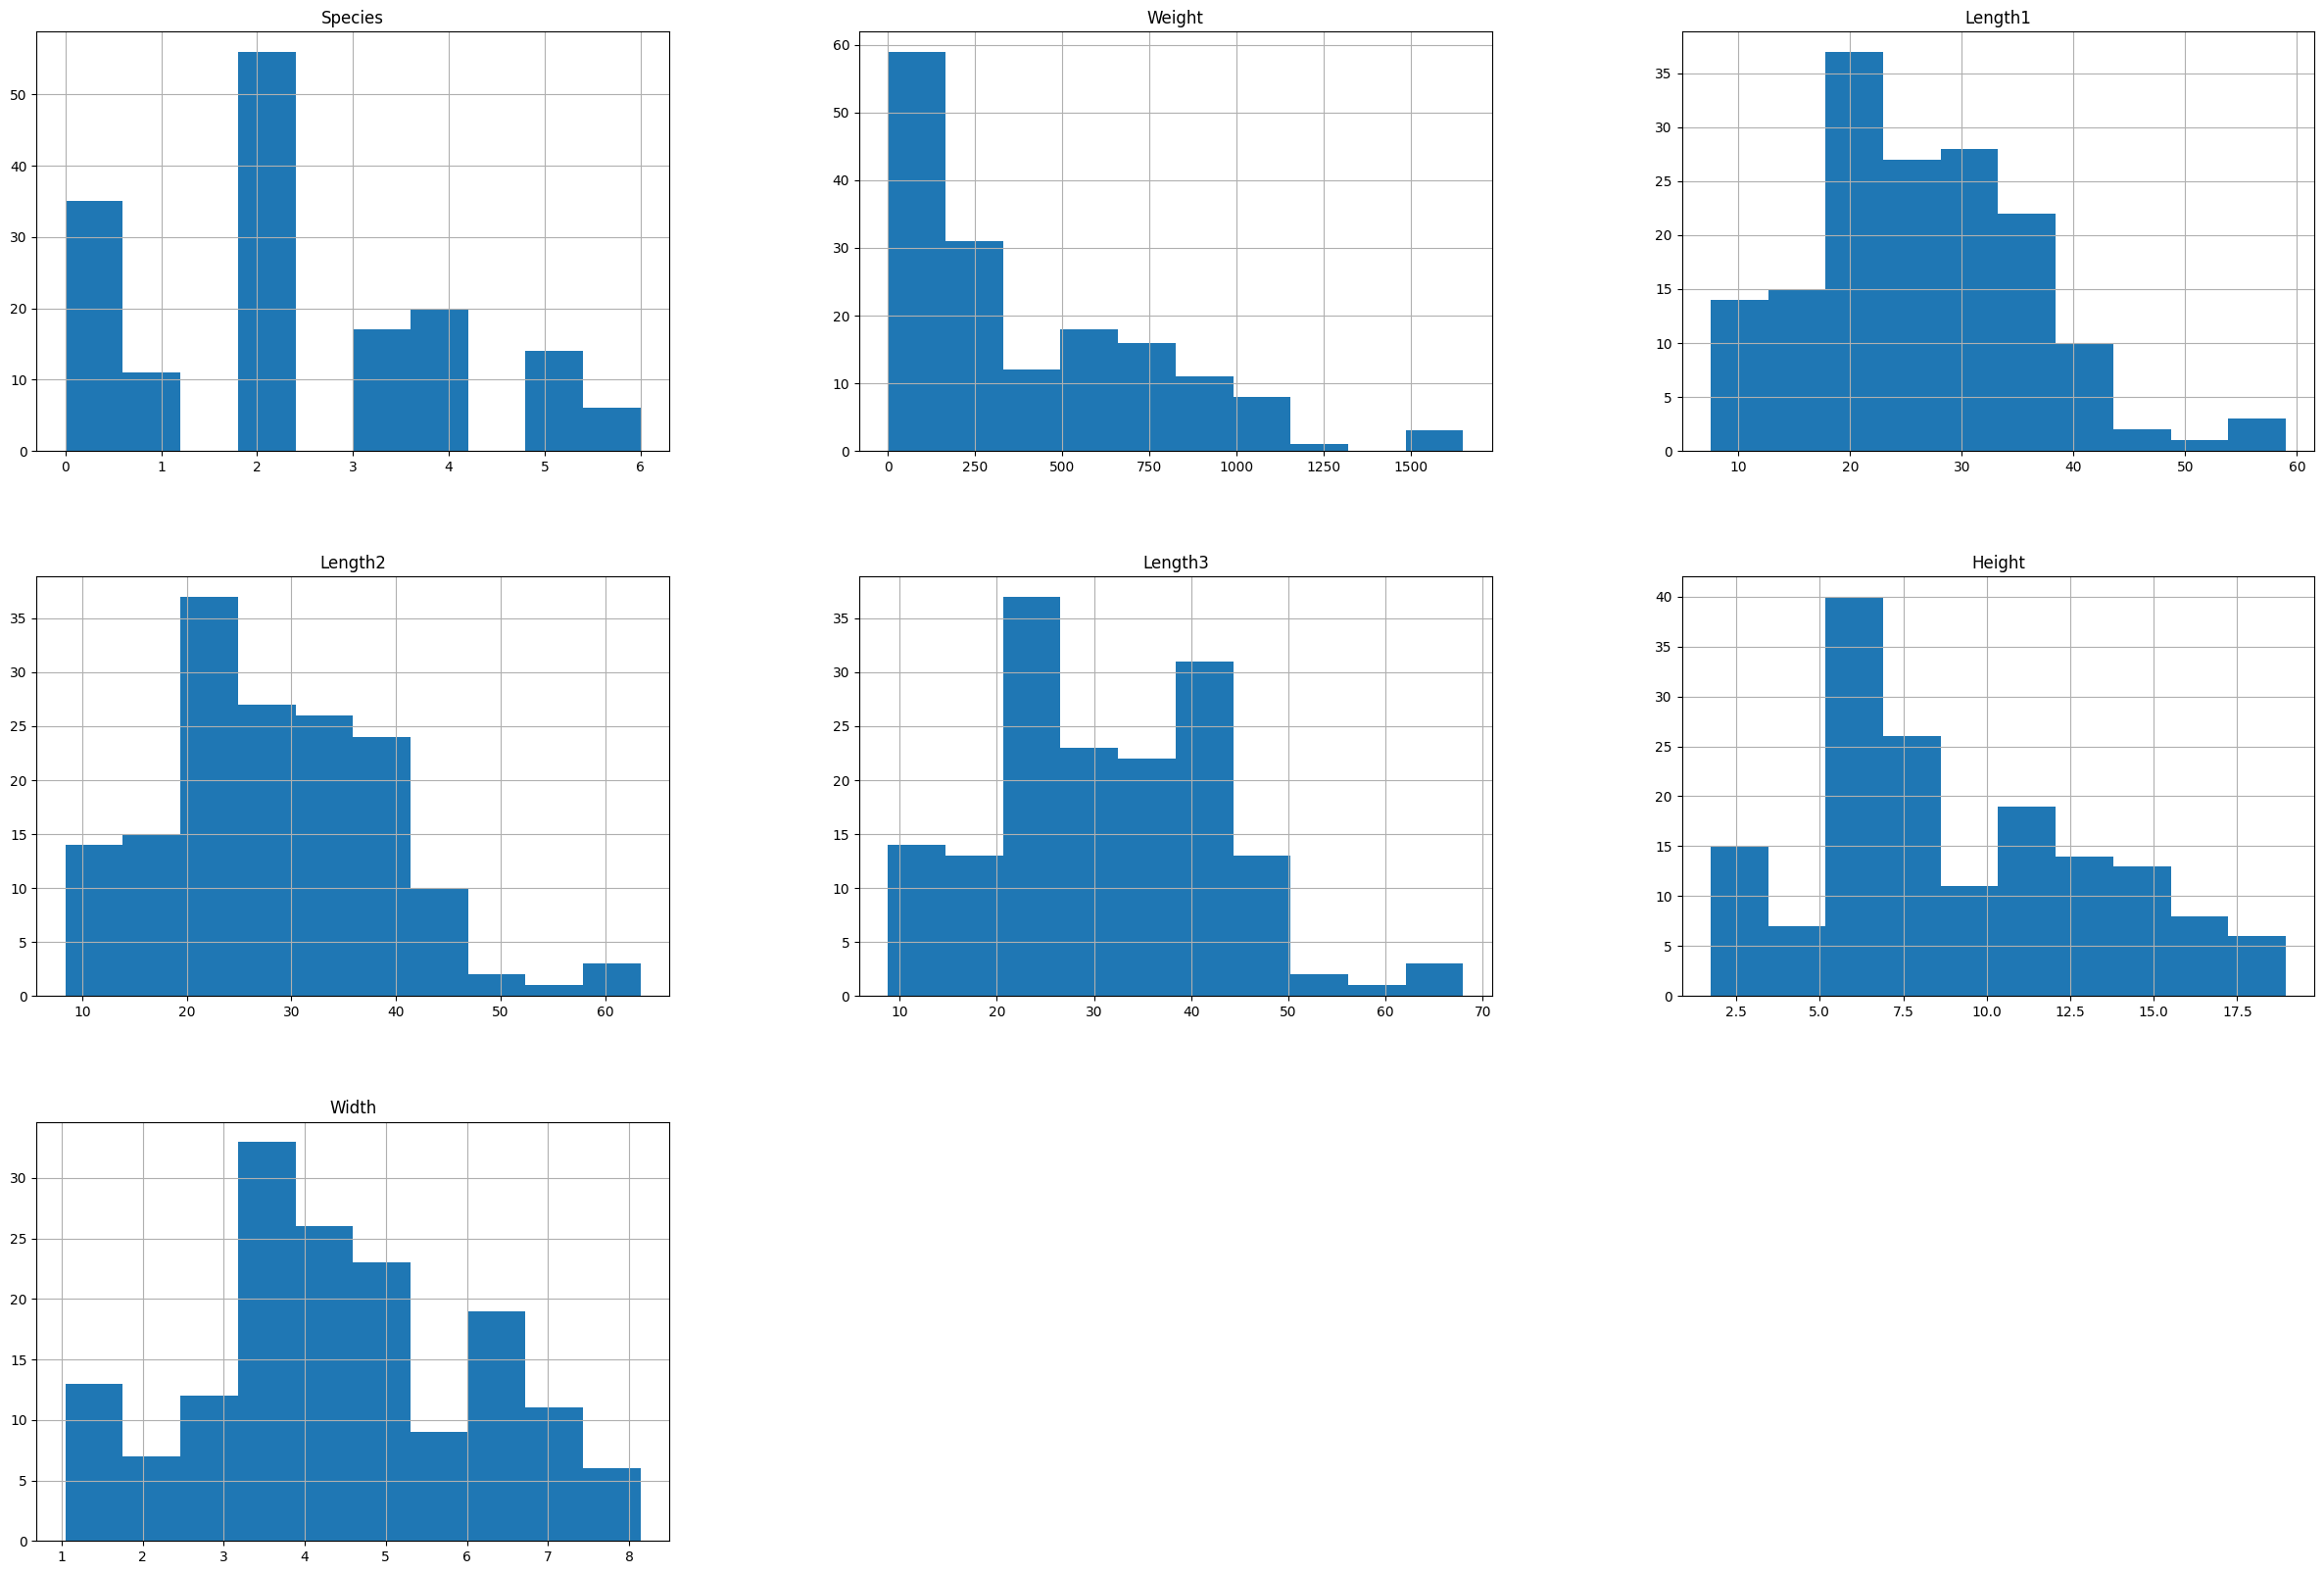

In [54]:
df.hist()

Since the distributions look mainly gaussian, I believe a standardization would fix the skewdness. Species looks funny but thats because we encoded categorical data into nermical so I didn't expect any distribution anyways.

In [55]:
df["Weight"] = np.sqrt(df["Weight"])

This is me from the future, I have decided to sqaure the weight coloumn due to its skewedness in order to improve performance. I tried log but it didn't look that much better. SPOILER ITS AWESOME. After looking at the final performance, the performance went up like 10%. Although the graph didn't really change much.

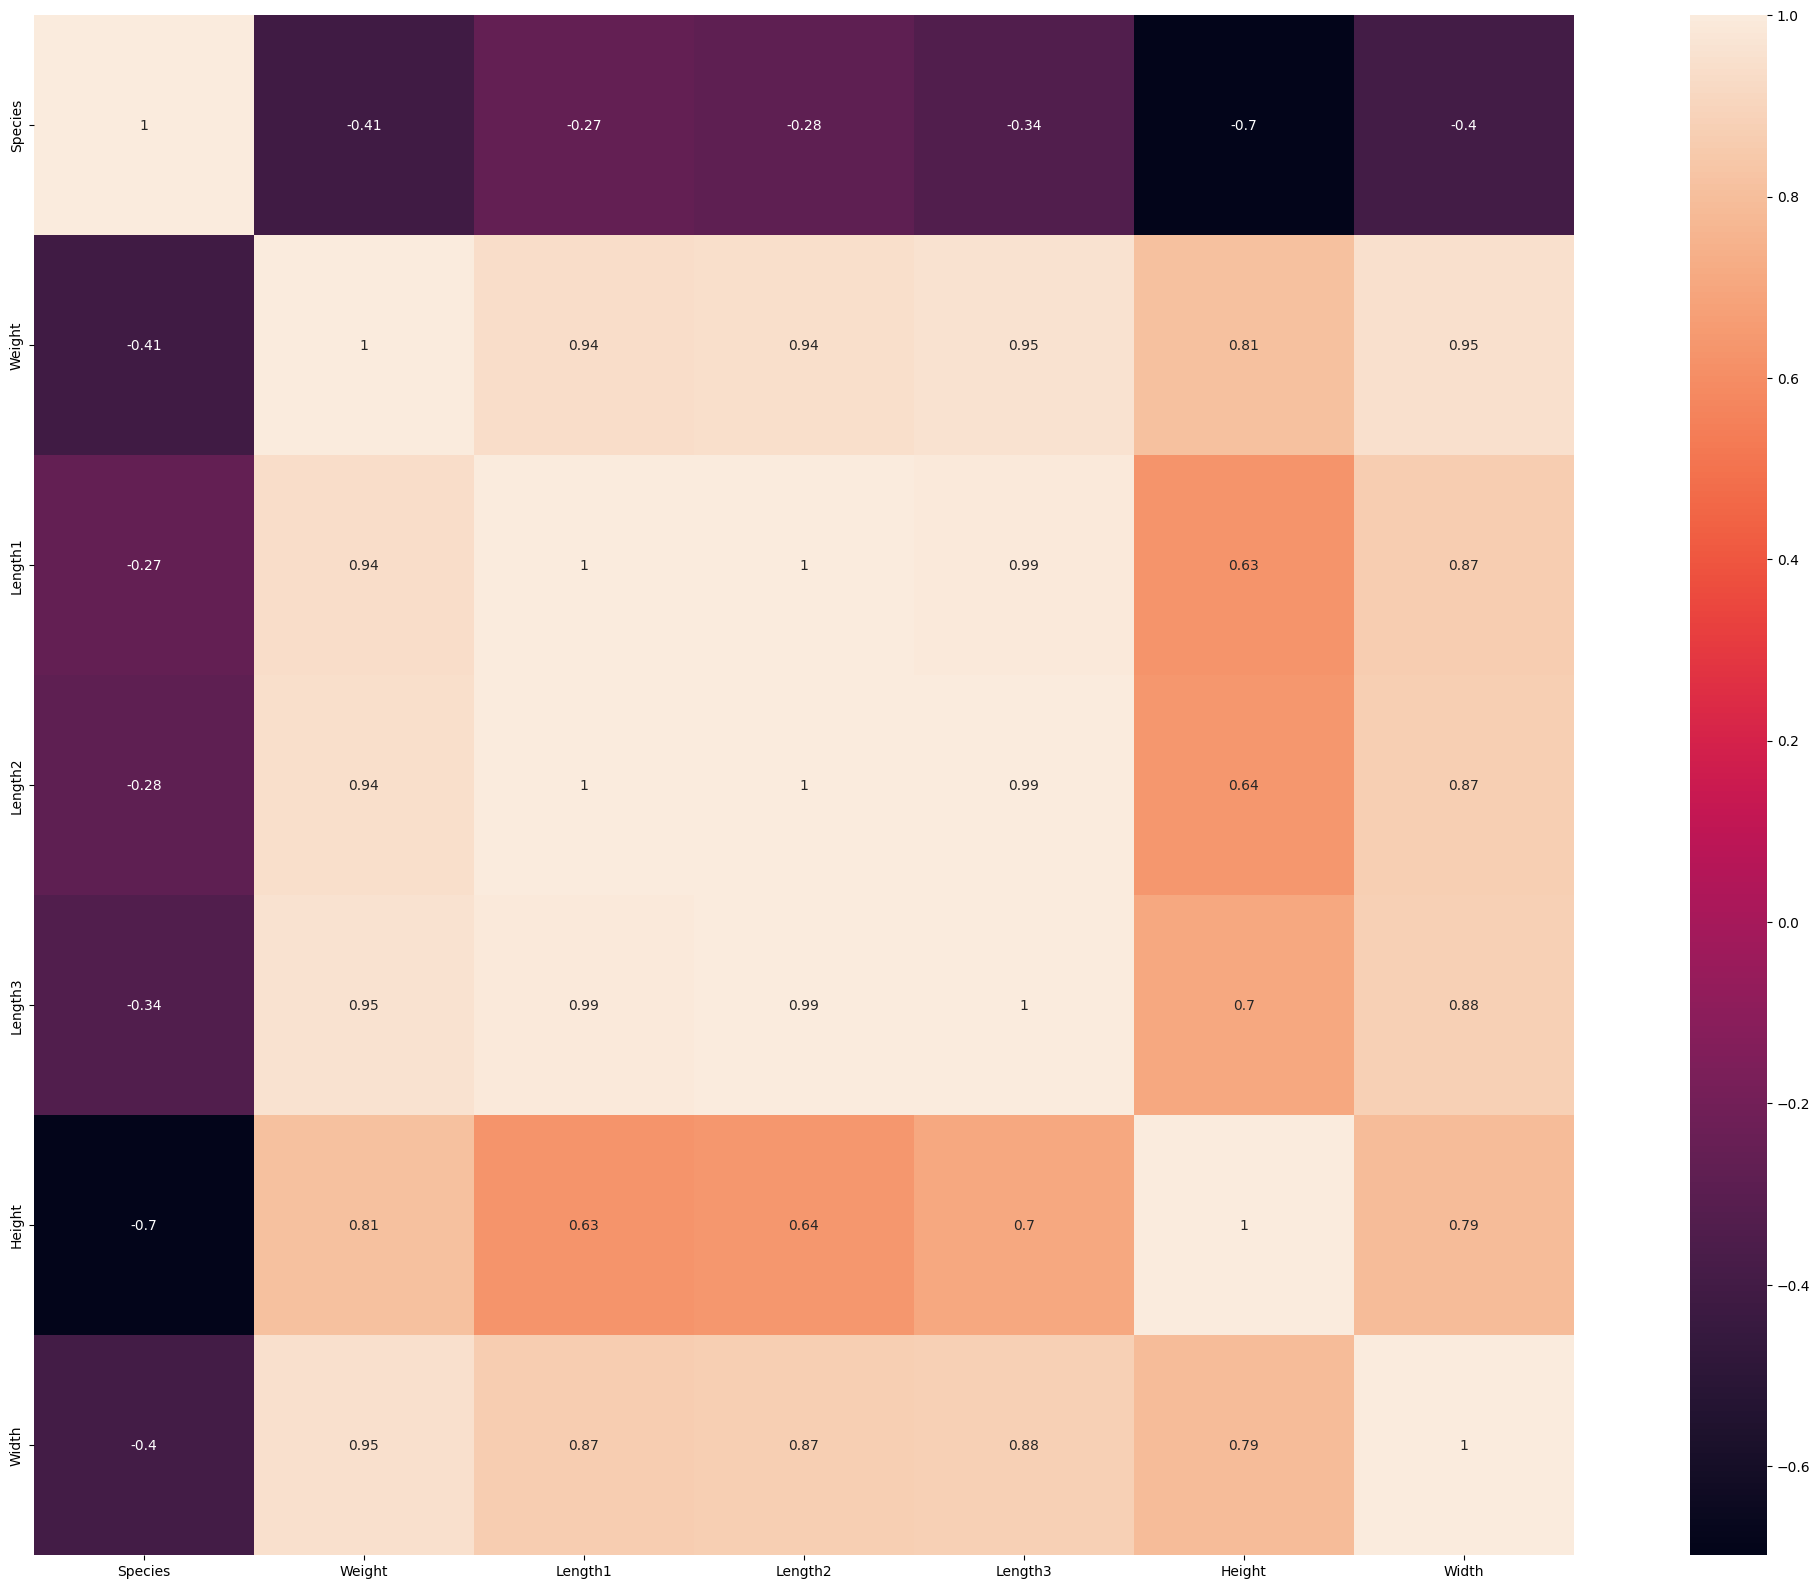

In [56]:
plt.figure()
map = df.corr(method="pearson")
sns.heatmap(map, square=True, annot=True)
plt.show()

<Figure size 3000x2000 with 0 Axes>

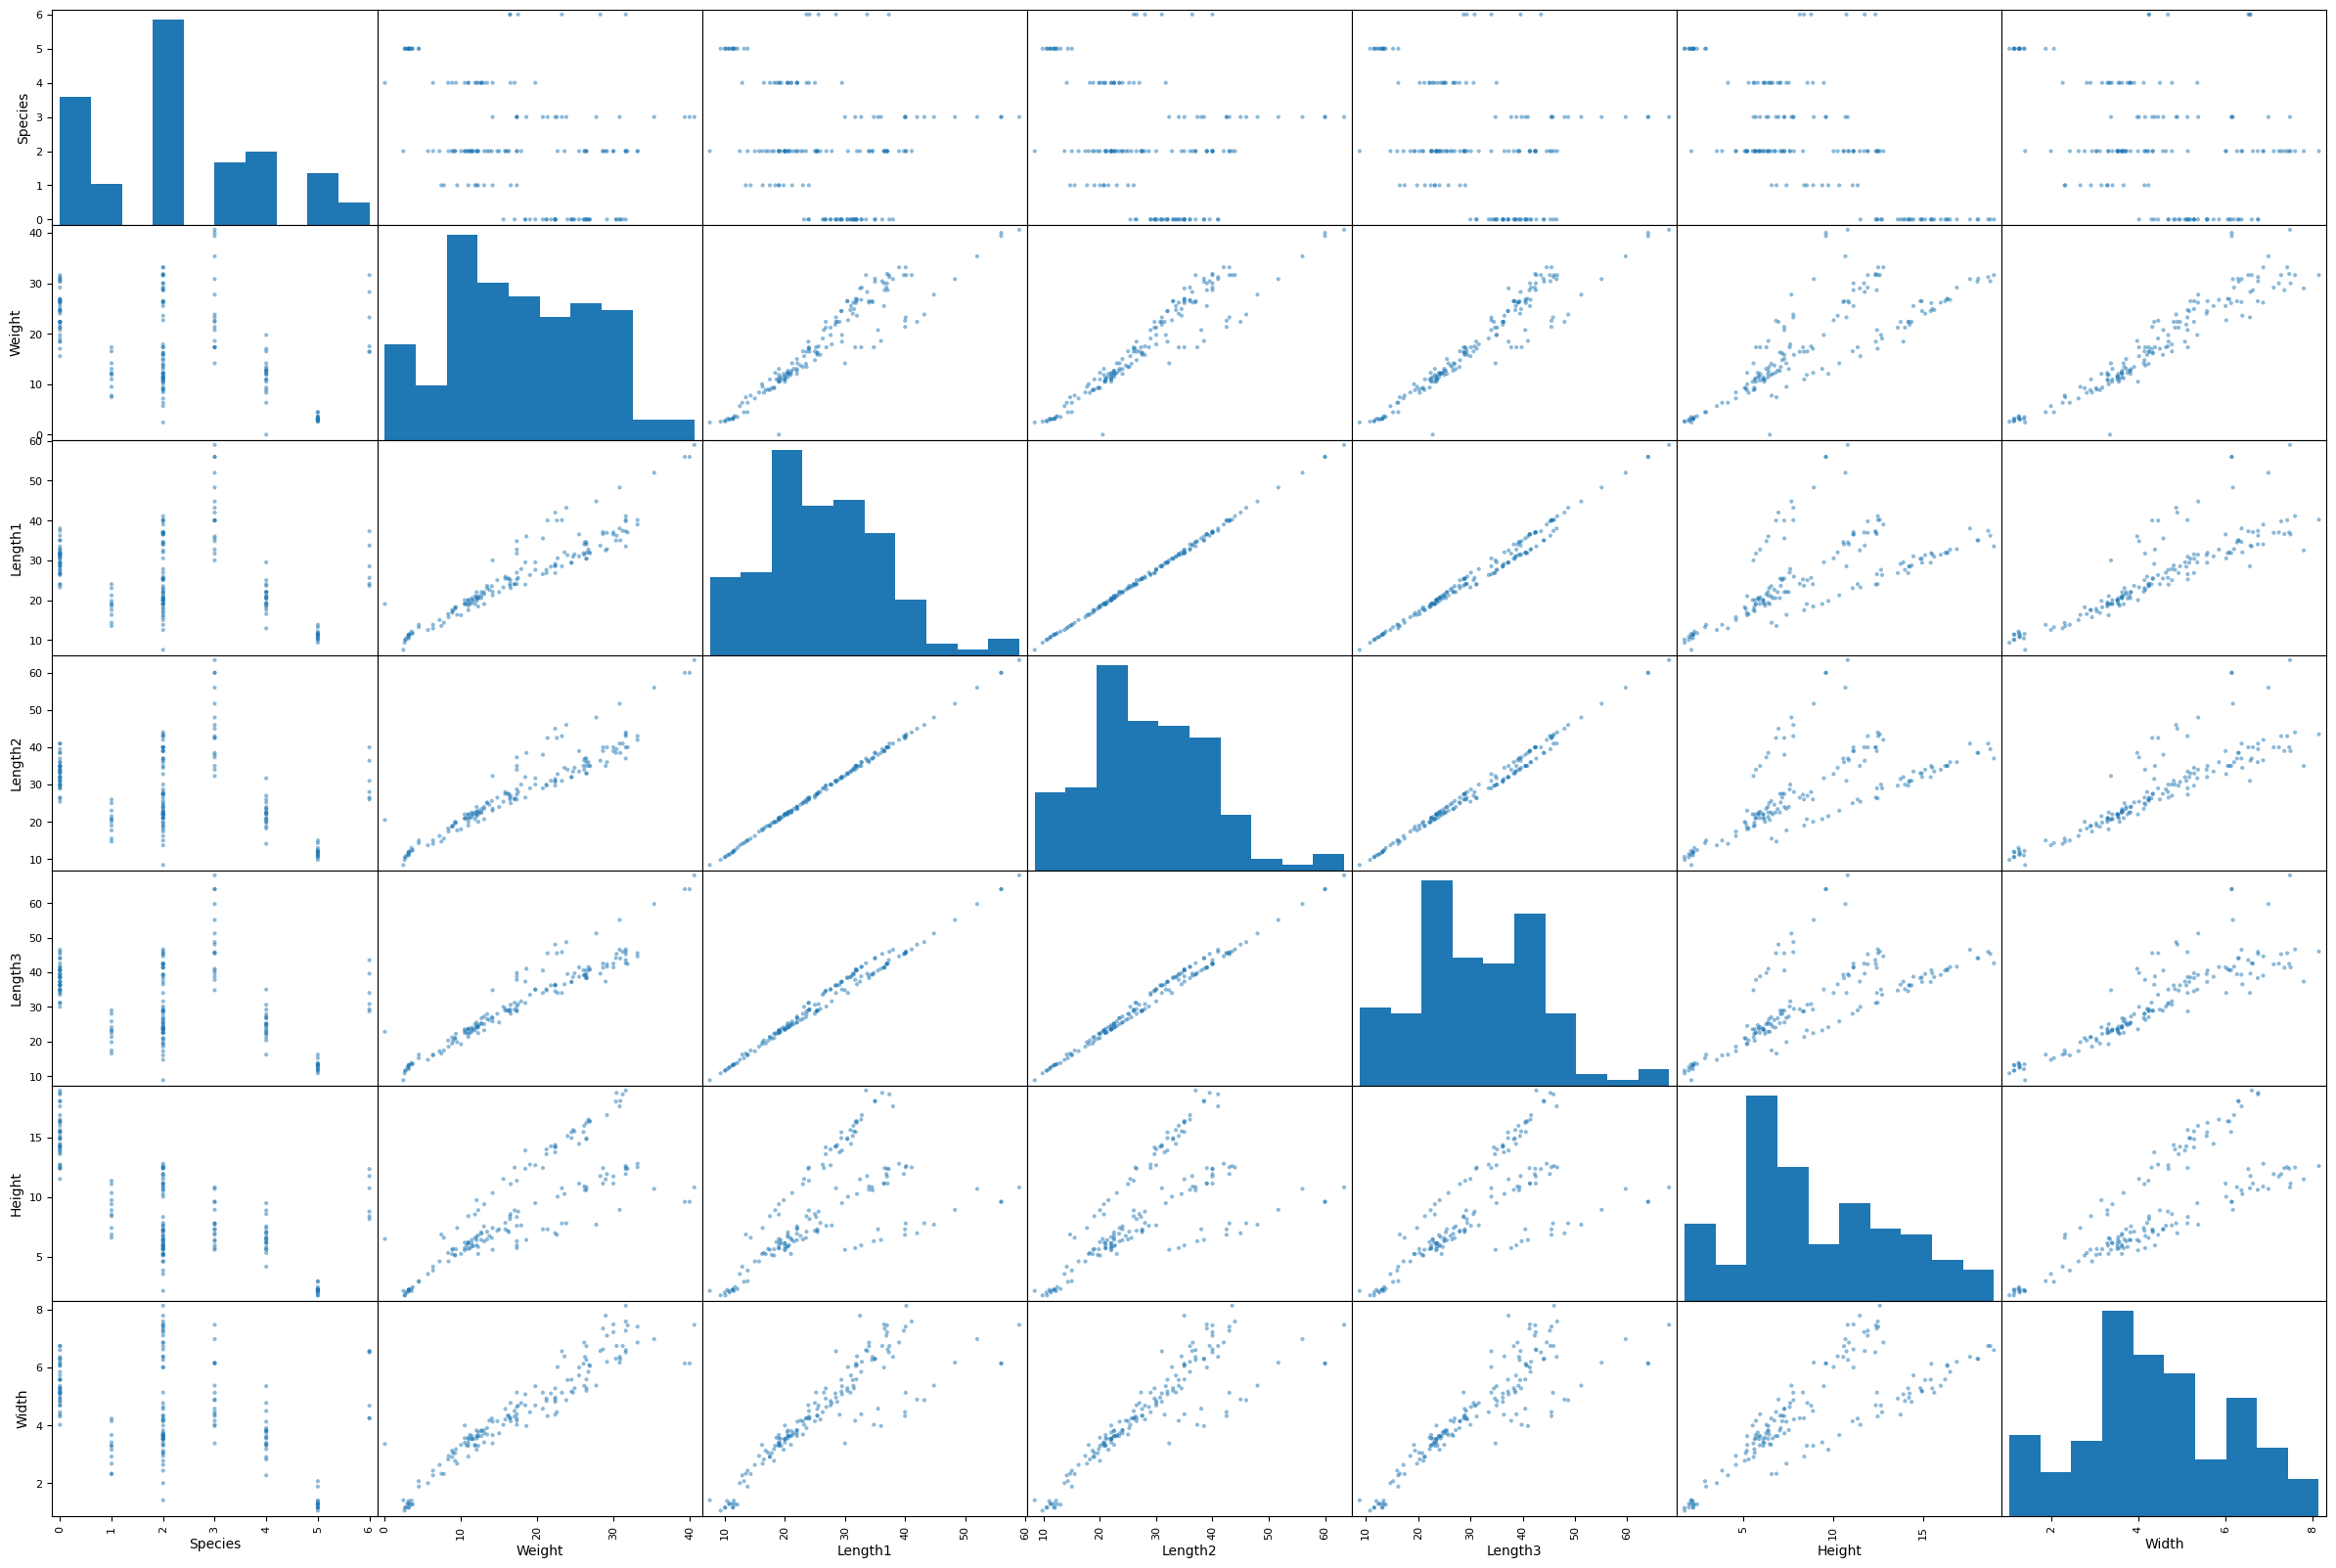

In [57]:
plt.figure()
scatter_matrix(df)
plt.show()

From this small dataset many of the input features have a strong correlation with the weight except for Species. I am now expecting to drop only a few, if any, features from the final model. However the relationship seems to stray a little from a linear pattern. I still think linear regression should be able to do a good enough job however. (I also didnt learn a non-linear method yet)

# Feature Selection

In [58]:
# Splitting the data
X = df.drop("Weight", axis=1)
Y = df.drop(["Species", "Length1", "Length2", "Length3", "Height", "Width"], axis=1)

scaler = StandardScaler().fit(X)
X = pd.DataFrame(scaler.transform(X), columns=X.columns)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

print(x_train, y_train)


      Species   Length1   Length2   Length3    Height     Width
85  -0.155485 -0.697160 -0.666106 -0.728122 -0.605469 -0.525730
81  -0.155485 -0.807547 -0.787799 -0.883647 -0.910194 -0.979168
112 -0.155485  0.778009  0.756772  0.671606  0.447025  1.455830
11  -1.332730  0.246146  0.241915  0.429678  1.263931  0.236308
109 -0.155485  0.426779  0.410414  0.239592  0.247854  0.952407
..        ...       ...       ...       ...       ...       ...
71  -0.744108 -0.225507 -0.226137 -0.192423  0.561004 -0.109185
106 -0.155485 -0.034839 -0.038916 -0.157862 -0.269289 -0.126918
14  -1.332730  0.316392  0.335526  0.516081  1.400378  0.448270
92  -0.155485 -0.576738 -0.553773 -0.624438 -0.509980 -0.472174
102 -0.155485 -0.105085 -0.104443 -0.218344 -0.151659  0.428335

[111 rows x 6 columns]         Weight
85   11.401754
81    9.219544
112  26.172505
11   22.360680
109  22.671568
..         ...
71   17.320508
106  15.811388
14   24.494897
92   12.247449
102  17.320508

[111 rows x 1 columns]


In [59]:
scores = []
variances = []
r2s = []
models = []

model = LinearRegression()
for i in range(1, len(X.columns)+1):
    
    linear_reg = RFE(model, n_features_to_select=i)
    linear_reg.fit(x_train, y_train)
    
    models.append((f"linear{i}", linear_reg))
    
    score = linear_reg.score(x_test, y_test)
    scores.append(scores)
    
    yhat = linear_reg.predict(x_test)
    r2 = r2_score(yhat, y_test)
    r2s.append(r2)
    
    var = float(np.var(yhat))
    variances.append(var)
    
    print(f"linear{i}: score:{score}, r2:{r2}, var:{var}")

linear1: score:0.8756685736675085, r2:0.852471701908415, var:74.64681869353181
linear2: score:0.9068293899799658, r2:0.8999484563420153, var:82.48231952872554
linear3: score:0.9247815229232988, r2:0.9203216534451516, var:83.61610684714974
linear4: score:0.9761330964463615, r2:0.9771093908424148, var:92.35160511376584
linear5: score:0.9790848796824354, r2:0.9798965903570992, var:92.15021760135328
linear6: score:0.9811790063555416, r2:0.981935817941509, var:92.28475562614659


I have no idea whats going on with the variance

In [60]:
# plt.figure()
# plt.plot(range(1, len(scores) + 1), scores, color="blue", label="scores")
# plt.plot(range(1, len(mses) + 1), mses, color="red", label="mse")
# plt.plot(range(1, len(variances) + 1), variances, color="green", label="variance")
# plt.legend()
# plt.xlabel("Complexity")
# plt.show()

Was hoping to plot MSE, Var against complexity but both the variance and mse were very large numbers and I was unsuer of why. I then swapped to r2 in order to gauge the error. Also this plot wouldnt load. 

In [61]:
alphas = [0.00001, 0.0005, 0.0001, 0.001, 0.01, 0.1]

for alpha in alphas:
    ridge = Ridge(alpha)
    lasso = Lasso(alpha, max_iter=int(10e5))
    
    ridge.fit(x_train, y_train)
    lasso.fit(x_train, y_train)
    
    rName = f"ridge{alpha}"
    lName = f"lasso{alpha}"
    
    models.append((rName, ridge))
    models.append((lName, lasso))
    
    rPredict = ridge.predict(x_test)
    lPredict = lasso.predict(x_test)
    
    rMse = mean_squared_error(rPredict, y_test)
    lMse = mean_squared_error(lPredict, y_test)
    
    rScore = ridge.score(x_test, y_test)
    lScore = lasso.score(x_test, y_test)
    
    print(f"{rName}: Score:{rScore}, Mse:{rMse}")
    print(f"{lName}: Score:{lScore}, Mse:{lMse}\n")
    
    

ridge1e-05: Score:0.981178968643308, Mse:1.6670519671733002
lasso1e-05: Score:0.9811804035677643, Mse:1.6669248703318926

ridge0.0005: Score:0.981177037312373, Mse:1.6672230326677164
lasso0.0005: Score:0.9811447779770461, Mse:1.670080367496882

ridge0.0001: Score:0.9811786260932752, Mse:1.6670823081623378
lasso0.0001: Score:0.9811907862634921, Mse:1.6660052345792253

ridge0.001: Score:0.9811749078508647, Mse:1.6674116473578025
lasso0.001: Score:0.9810180804951119, Mse:1.6813024563660697

ridge0.01: Score:0.9811201279297167, Mse:1.6722637180855273
lasso0.01: Score:0.979124149070472, Mse:1.8490553306534103

ridge0.1: Score:0.9805030864806006, Mse:1.7269174797249391
lasso0.1: Score:0.9788259710249485, Mse:1.8754661201546423



### K-Fold Cross Validation Function

In [62]:
results = []
names = []

def cross_validation(models, measure):
    
    for name, model in models:
        kfold = KFold()
        cv_results = cross_val_score(model, x_train, y_train, cv=kfold, scoring=measure)
        results.append(cv_results)
        names.append(name)
        print(f"{name}, {cv_results.mean()}, {cv_results.std()}, {cv_results}")

cross_validation(models, "r2")

linear1, 0.8899212049426304, 0.03978383071611691, [0.85191294 0.88847368 0.9625162  0.85535292 0.89135029]
linear2, 0.9253488100652124, 0.0355752907862907, [0.89618233 0.93222966 0.9583037  0.87371604 0.96631232]
linear3, 0.9302833319334433, 0.033449404849031396, [0.90337    0.93185496 0.96608481 0.8830352  0.9670717 ]
linear4, 0.9648967509414174, 0.01670846695472478, [0.95902928 0.93739691 0.98258928 0.96353304 0.98193525]
linear5, 0.970352412546552, 0.01697399943848973, [0.97565869 0.93763517 0.98466804 0.97183413 0.98196603]
linear6, 0.9705590436586418, 0.017618357231405965, [0.97580381 0.93652274 0.98509007 0.97253065 0.98284795]
ridge1e-05, 0.9705592088018065, 0.017618498606632216, [0.97580438 0.93652264 0.98509004 0.97253049 0.98284849]
lasso1e-05, 0.970556876437571, 0.01761998903978677, [0.97580004 0.93651922 0.98508667 0.97252147 0.98285697]
ridge0.0005, 0.9705670567534156, 0.01762521984862348, [0.97583232 0.93651765 0.98508881 0.97252295 0.98287355]
lasso0.0005, 0.970460016432

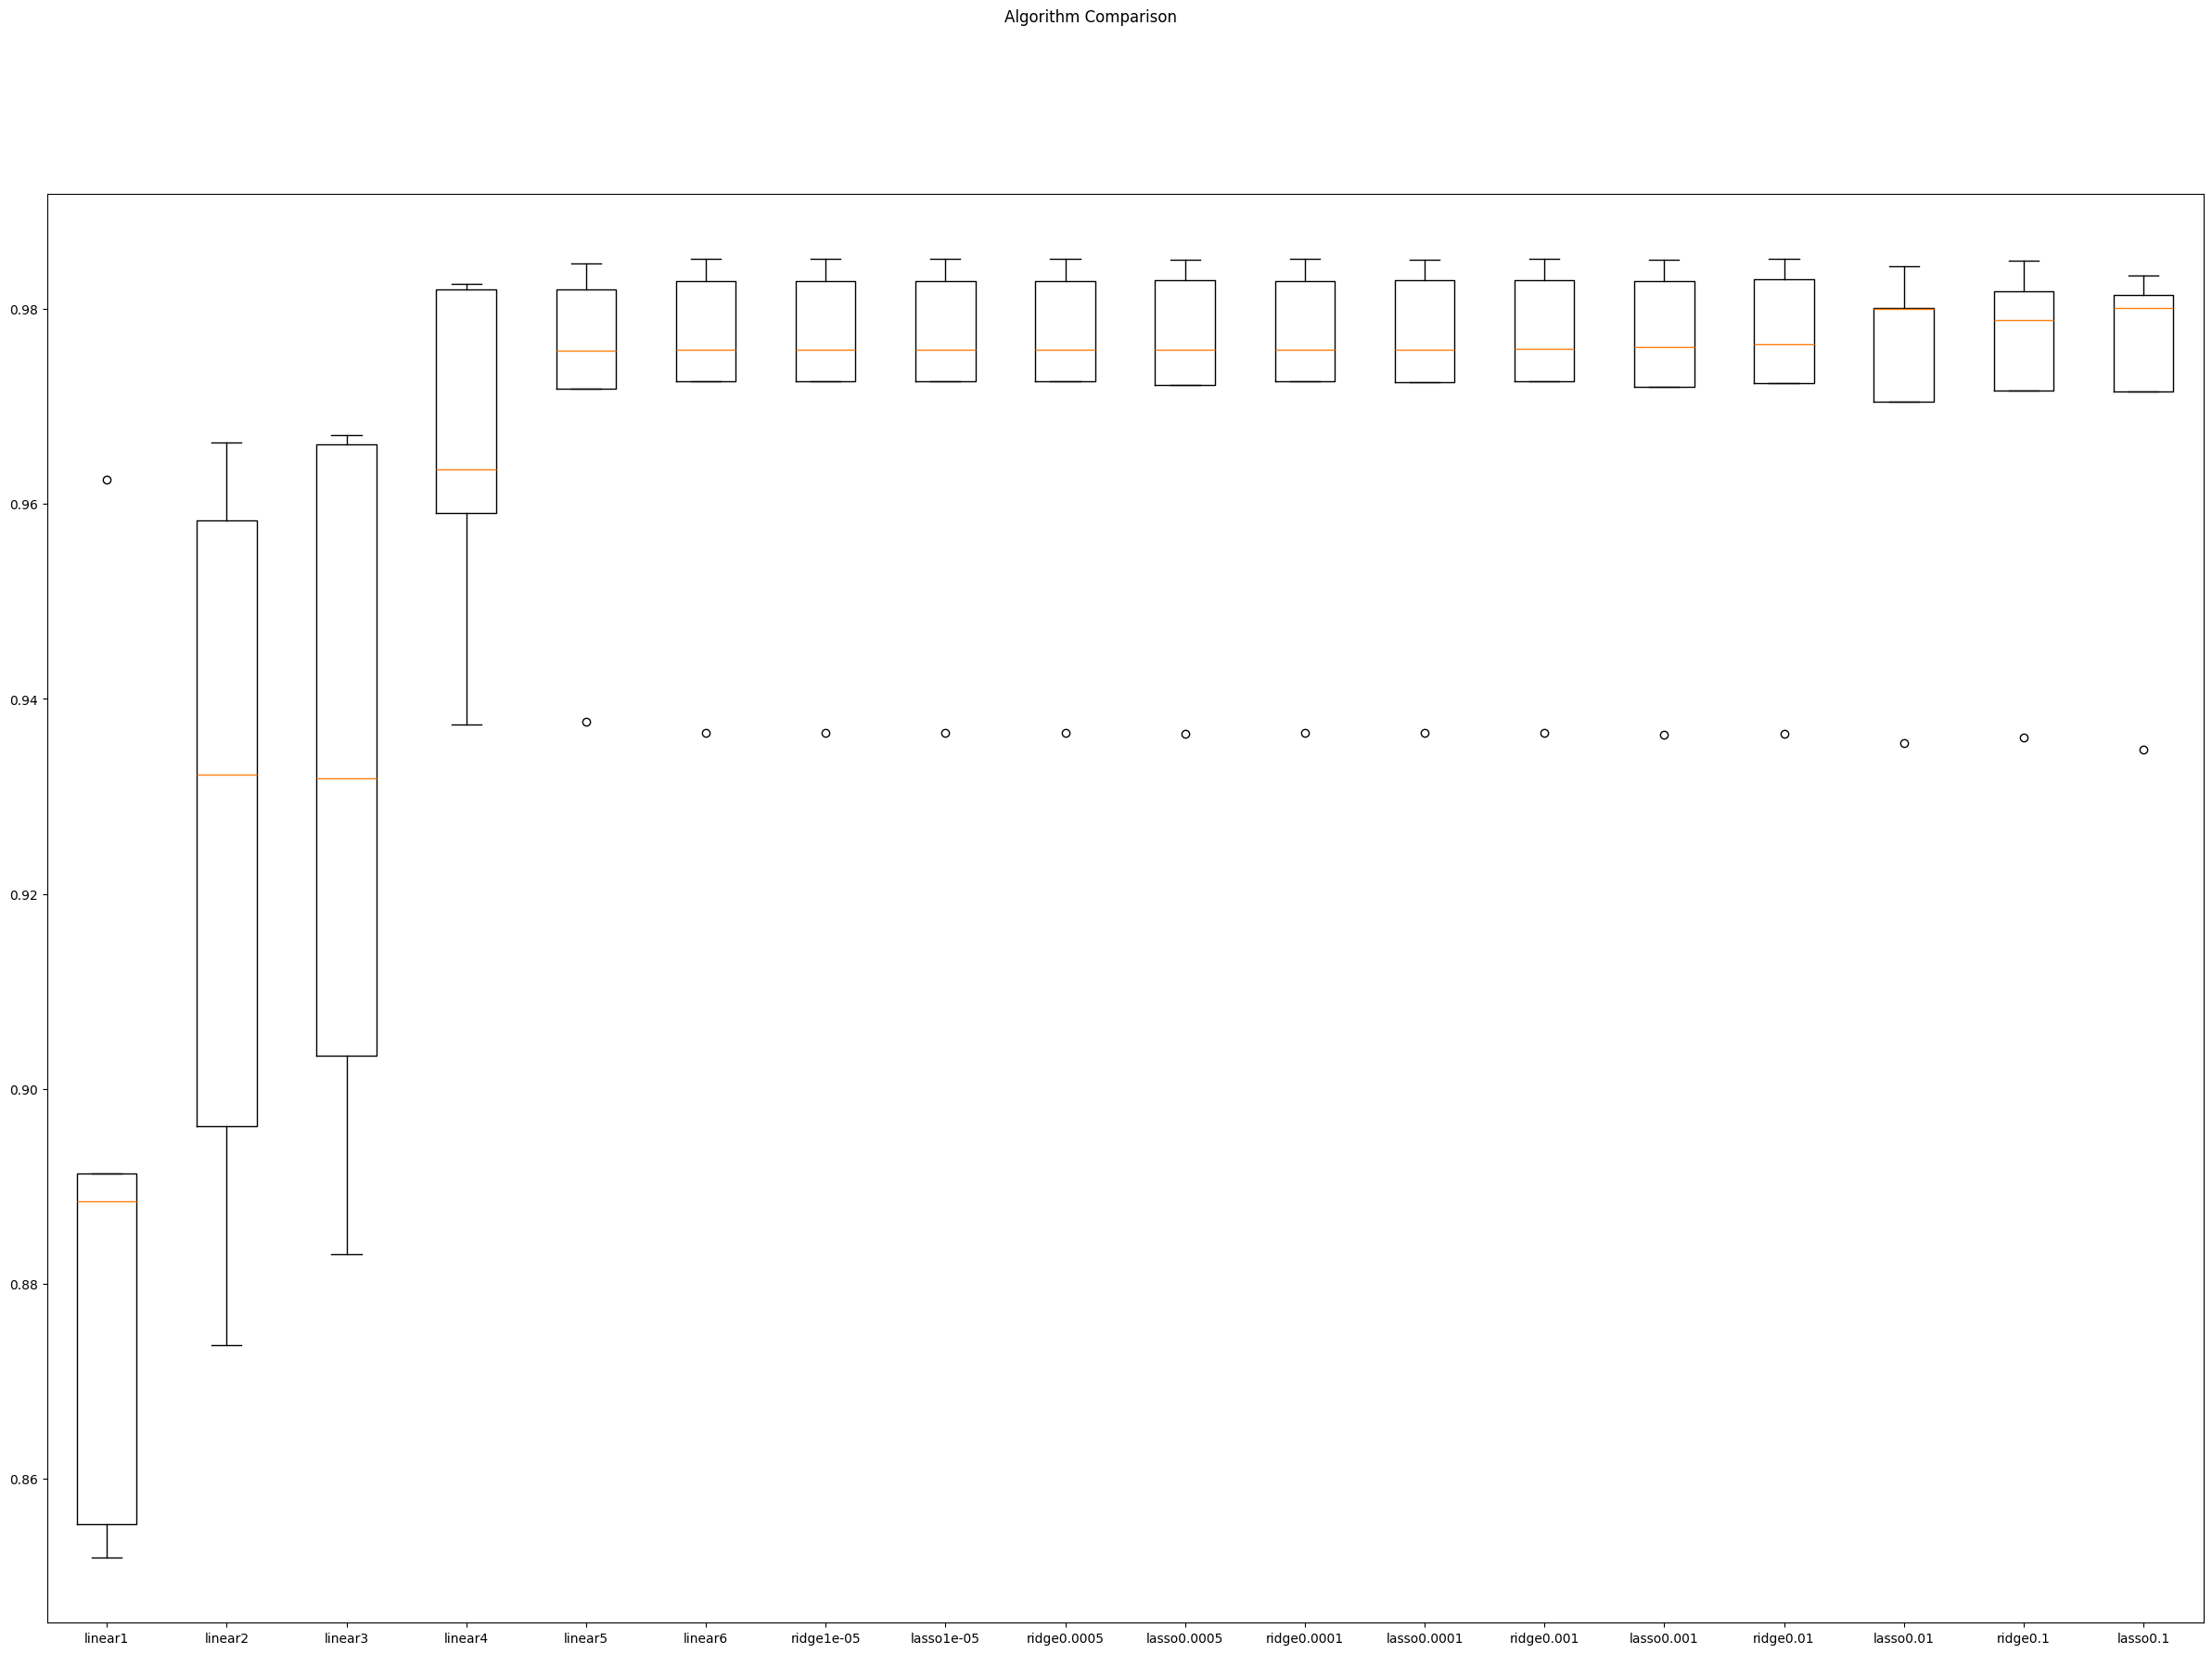

In [63]:
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.rcParams['figure.figsize'] = [30, 20]
plt.show()

This result comes after squarerooting the weight coloumn which increased the overall accuracy by 10% which is huge. Before most of the distributions looked about the same with the Ridge with alpha 0.1 having the best perforance and least variance. After the changes this still seems to be the best fit although it is agruably hard to tell as most of the regularized models including the overfitted linear6 are very very similar. 